# S2. Ligand-distribution-matched mechanism control

This notebook tests the specific alternative explanation that the apparent advantage of mechanism-aligned Ru-AHK data is caused simply by **ligand-space proximity to the Ru-AHO target**.

The control is deliberately constructed to favor the mechanism-mismatched source:

1. Load the already-cleaned domains produced by `0_1_clean_ru_aho_and_build_ru_ahk_domains.ipynb`. **No mechanism assignment is performed here.**
2. Keep the complete inner-sphere Ru-AHK source as the mechanism-aligned source. Its reaction count defines the fixed source size $N$.
3. From the outer-sphere Ru-AHK pool, select exactly the same number $N$ of reactions using **ligand structure only**. No $\Delta\Delta G^{\ddagger}$ labels, substrate identities, solvents, additives, pressure, temperature, or S/C values enter source selection.
4. Ligand distributions are compared with the same four full-distribution metrics used in `0_2_dataset_overview_distribution_metrics.ipynb`: RBF-MMD, energy distance, sliced Wasserstein distance, and symmetric kNN distance in one shared standardized MACCS space. Lower is closer.
5. Candidate outer subsets are ranked by their distances relative to the aligned inner source. The search minimizes the **worst normalized distance ratio** across the four metrics. A strict ligand match is achieved when the selected outer subset is closer to Ru-AHO than the aligned inner source on all four metrics.
6. Freeze the selected outer subset and compare target-only, mechanism-aligned transfer, and ligand-distribution-matched but mechanism-mismatched transfer under the same target splits, MACCS/SPOC representations, algorithms, mixed transfer, and delta learning.

Using the complete unlabeled Ru-AHO ligand distribution for source selection makes this a deliberately stringent, source-selection control. Target $\Delta\Delta G^{\ddagger}$ labels are never used to choose the outer subset.


In [1]:
from __future__ import annotations

import hashlib
import json
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray

from scipy.stats import gaussian_kde, wasserstein_distance

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, pairwise_distances, r2_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
TARGET_COLUMN = "ddG"
KNN_K = 10
SLICED_PROJECTIONS = 128
SLICED_QUANTILES = 256

# Search budget. Increase these only if the fixed-size ligand match is difficult.
N_RANDOM_CANDIDATES = 1800
LOCAL_RESTARTS = 10
LOCAL_STEPS_PER_RESTART = 700

FORCE_RECOMPUTE_SELECTION = False
FORCE_RECOMPUTE_FEATURES = False
FORCE_RECOMPUTE_RESULTS = False

COMPONENT_COLS = [
    "Reactant SMILES",
    "Product SMILES",
    "Ligand SMILES",
    "Solvent SMILES",
    "Additive SMILES",
]
CONDITION_COLS = ["Pressure/atm", "Temperature/C", "S/C"]

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "transfer").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
OUT_DIR = PROJECT_ROOT / "results" / "S2_ligand_distribution_matched_mechanism_control"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"
for directory in [OUT_DIR, TABLE_DIR, FIG_DIR, FEATURE_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DOMAIN_FILES = OrderedDict([
    ("ru_ahk_inner", TRANSFER_DIR / "ru_ahk_inner.csv"),
    ("ru_ahk_outer", TRANSFER_DIR / "ru_ahk_outer.csv"),
    ("ru_aho_inner", TRANSFER_DIR / "ru_aho_inner.csv"),
])

SELECTION_PATH = TABLE_DIR / "selected_outer_ligand_distribution_matched_subset.csv"
SELECTION_META_PATH = TABLE_DIR / "selection_metadata.json"
LIGAND_AUDIT_PATH = TABLE_DIR / "ligand_distribution_match_audit.csv"
POSTHOC_AUDIT_PATH = TABLE_DIR / "posthoc_covariate_and_ddG_audit.csv"
OOF_PATH = TABLE_DIR / "oof_predictions.csv"
SCORE_PATH = TABLE_DIR / "pooled_oof_metrics.csv"
PAIRWISE_PATH = TABLE_DIR / "aligned_vs_ligand_matched_outer_modelwise.csv"
BEST_PATH = TABLE_DIR / "best_outcome_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUT_DIR)


Project root: /home/syz/ru-mechanism-transfer
Output directory: /home/syz/ru-mechanism-transfer/results/S2_ligand_distribution_matched_mechanism_control


## 1. Load the three current mechanistic domains

The mechanism labels have already been established upstream. This notebook only reads `ru_ahk_inner.csv`, `ru_ahk_outer.csv`, and `ru_aho_inner.csv` and never infers mechanism from structure.

In [2]:
TARGET_COL_CANDIDATES = ["ddG", "DeltaDeltaG", "ΔΔG‡", "target", "Target", "y"]


def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def infer_target_column(df: pd.DataFrame) -> str:
    for col in TARGET_COL_CANDIDATES:
        if col in df.columns:
            return col
    for col in df.columns:
        low = str(col).lower()
        if "ddg" in low or "delta" in low:
            return col
    raise KeyError(f"Cannot infer target column from columns: {list(df.columns)}")


def canonicalize_smiles(value) -> str:
    if pd.isna(value):
        return ""
    smi = str(value).strip()
    if not smi or smi.lower() in {"nan", "none", "null"}:
        return ""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return ""
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)


def load_domain(path: Path, domain_key: str) -> pd.DataFrame:
    df = pd.read_csv(require_file(path)).copy()
    y_col = infer_target_column(df)
    df[TARGET_COLUMN] = pd.to_numeric(df[y_col], errors="coerce")
    df = df.loc[df[TARGET_COLUMN].notna()].reset_index(drop=True)

    for col in COMPONENT_COLS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].map(canonicalize_smiles)

    for col in CONDITION_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Metal" not in df.columns:
        df["Metal"] = "Ru"
    df["Metal"] = df["Metal"].fillna("Ru").astype(str).str.strip().str.capitalize()

    df["domain_key"] = domain_key
    df["domain_row"] = np.arange(len(df), dtype=int)
    df["record_id"] = [f"{domain_key}__{i:05d}" for i in range(len(df))]
    return df


DOMAINS = OrderedDict((key, load_domain(path, key)) for key, path in DOMAIN_FILES.items())
INNER_DF = DOMAINS["ru_ahk_inner"]
OUTER_DF = DOMAINS["ru_ahk_outer"]
TARGET_DF = DOMAINS["ru_aho_inner"]
SOURCE_SIZE = len(INNER_DF)

if len(OUTER_DF) < SOURCE_SIZE:
    raise ValueError(
        f"Outer source has only {len(OUTER_DF)} reactions, smaller than the aligned source ({SOURCE_SIZE})."
    )

DOMAIN_SUMMARY = pd.DataFrame([
    {
        "domain": key,
        "n_reactions": len(df),
        "n_substrates": df["Reactant SMILES"].nunique(),
        "n_ligand_systems": df["Ligand SMILES"].nunique(),
        "ddG_median": df[TARGET_COLUMN].median(),
    }
    for key, df in DOMAINS.items()
])
display(DOMAIN_SUMMARY)
print("Fixed source size N =", SOURCE_SIZE)


def dataframe_hash(df: pd.DataFrame, columns: list[str]) -> str:
    payload = df.loc[:, columns].fillna("<NA>").astype(str).to_csv(index=False).encode()
    return hashlib.sha256(payload).hexdigest()[:16]

DATA_HASH = hashlib.sha256(
    "|".join(
        dataframe_hash(df, COMPONENT_COLS + CONDITION_COLS + [TARGET_COLUMN])
        for df in DOMAINS.values()
    ).encode()
).hexdigest()[:16]
print("Current-domain hash:", DATA_HASH)


,domain,n_reactions,n_substrates,n_ligand_systems,ddG_median
0,ru_ahk_inner,495,214,41,2.132447
1,ru_ahk_outer,1539,345,304,1.965138
2,ru_aho_inner,98,38,22,1.963148


Fixed source size N = 495
Current-domain hash: 0155839dd5fe4717


## 2. Build one shared ligand MACCS space and reproduce the four distribution distances

Every unique canonical ligand system receives equal weight, matching the logic in `0_2_dataset_overview_distribution_metrics.ipynb`. The scaler, RBF bandwidth, and sliced-Wasserstein projection directions are fixed once from the pooled ligand union and reused for every candidate subset.

In [3]:
def maccs_vector(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid canonical SMILES: {smiles}")
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros(fp.GetNumBits(), dtype=np.int8)
    ConvertToNumpyArray(fp, arr)
    return arr[1:].astype(float)  # 166 defined bits; bit 0 is unused


def unique_valid_smiles(df: pd.DataFrame, col: str) -> list[str]:
    return sorted({s for s in df[col].map(canonicalize_smiles) if s})


INNER_LIGANDS = unique_valid_smiles(INNER_DF, "Ligand SMILES")
OUTER_LIGANDS = unique_valid_smiles(OUTER_DF, "Ligand SMILES")
TARGET_LIGANDS = unique_valid_smiles(TARGET_DF, "Ligand SMILES")
ALL_LIGANDS = sorted(set(INNER_LIGANDS) | set(OUTER_LIGANDS) | set(TARGET_LIGANDS))

raw_ligand_matrix = np.vstack([maccs_vector(s) for s in ALL_LIGANDS])
variable_bits = raw_ligand_matrix.var(axis=0) > 0
if int(variable_bits.sum()) < 1:
    raise ValueError("No variable MACCS bits in pooled ligand space.")

ligand_scaler = StandardScaler()
scaled_ligand_matrix = ligand_scaler.fit_transform(raw_ligand_matrix[:, variable_bits])
scaled_ligand_matrix = np.nan_to_num(scaled_ligand_matrix).astype(np.float32)
LIGAND_VECTOR = {s: scaled_ligand_matrix[i] for i, s in enumerate(ALL_LIGANDS)}
TARGET_LIGAND_MATRIX = np.vstack([LIGAND_VECTOR[s] for s in TARGET_LIGANDS]).astype(np.float32)

pooled_distances = pairwise_distances(scaled_ligand_matrix)
upper = pooled_distances[np.triu_indices_from(pooled_distances, k=1)]
upper = upper[np.isfinite(upper) & (upper > 0)]
median_distance = float(np.median(upper)) if len(upper) else 1.0
RBF_GAMMA = 1.0 / (2.0 * median_distance**2 + 1e-12)

_rng_proj = np.random.default_rng(RANDOM_STATE)
SW_DIRECTIONS = _rng_proj.normal(size=(SLICED_PROJECTIONS, scaled_ligand_matrix.shape[1]))
SW_DIRECTIONS /= np.linalg.norm(SW_DIRECTIONS, axis=1, keepdims=True) + 1e-12
SW_QUANTILES = np.linspace(0.0, 1.0, SLICED_QUANTILES)

LIGAND_INDEX = {s: i for i, s in enumerate(ALL_LIGANDS)}
TARGET_LIGAND_INDICES = np.array([LIGAND_INDEX[s] for s in TARGET_LIGANDS], dtype=int)

# Precompute all geometry once. Candidate evaluation then uses only small indexed submatrices,
# making the fixed-size ligand-set search fast enough for thousands of candidates.
LIGAND_DISTANCE_MATRIX = pairwise_distances(scaled_ligand_matrix).astype(np.float32)
LIGAND_RBF_MATRIX = np.exp(-RBF_GAMMA * LIGAND_DISTANCE_MATRIX**2).astype(np.float32)
LIGAND_PROJECTIONS = (scaled_ligand_matrix @ SW_DIRECTIONS.T).astype(np.float32)

METRIC_NAMES = ["rbf_mmd", "energy_distance", "sliced_wasserstein", "symmetric_knn_distance"]


def _median_mean_knn_from_distance_block(distance_block: np.ndarray, k: int) -> float:
    # Rows are queries and columns are reference points.
    k_eff = max(1, min(int(k), distance_block.shape[1]))
    nearest = np.partition(distance_block, kth=k_eff - 1, axis=1)[:, :k_eff]
    return float(np.median(nearest.mean(axis=1)))


def ligand_distribution_metrics(smiles_set) -> dict:
    smiles = sorted({canonicalize_smiles(s) for s in smiles_set if canonicalize_smiles(s)})
    if not smiles:
        return {name: np.inf for name in METRIC_NAMES} | {"n_unique_ligands": 0}

    source_idx = np.array([LIGAND_INDEX[s] for s in smiles], dtype=int)
    target_idx = TARGET_LIGAND_INDICES

    Kxx = LIGAND_RBF_MATRIX[np.ix_(source_idx, source_idx)]
    Kyy = LIGAND_RBF_MATRIX[np.ix_(target_idx, target_idx)]
    Kxy = LIGAND_RBF_MATRIX[np.ix_(source_idx, target_idx)]
    mmd2 = float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

    Dxx = LIGAND_DISTANCE_MATRIX[np.ix_(source_idx, source_idx)]
    Dyy = LIGAND_DISTANCE_MATRIX[np.ix_(target_idx, target_idx)]
    Dxy = LIGAND_DISTANCE_MATRIX[np.ix_(source_idx, target_idx)]
    energy = float(max(2.0 * Dxy.mean() - Dxx.mean() - Dyy.mean(), 0.0))

    projected_x = LIGAND_PROJECTIONS[source_idx]
    projected_y = LIGAND_PROJECTIONS[target_idx]
    qx = np.quantile(projected_x, SW_QUANTILES, axis=0)
    qy = np.quantile(projected_y, SW_QUANTILES, axis=0)
    sw = float(np.mean(np.abs(qx - qy)))

    source_to_target = _median_mean_knn_from_distance_block(Dxy, KNN_K)
    target_to_source = _median_mean_knn_from_distance_block(Dxy.T, KNN_K)
    knn = 0.5 * (source_to_target + target_to_source)

    return {
        "n_unique_ligands": len(smiles),
        "rbf_mmd": float(np.sqrt(max(mmd2, 0.0))),
        "energy_distance": energy,
        "sliced_wasserstein": sw,
        "symmetric_knn_distance": float(knn),
    }


INNER_LIGAND_METRICS = ligand_distribution_metrics(INNER_LIGANDS)
FULL_OUTER_LIGAND_METRICS = ligand_distribution_metrics(OUTER_LIGANDS)

baseline_table = pd.DataFrame([
    {"source": "Aligned inner Ru-AHK", **INNER_LIGAND_METRICS},
    {"source": "Full outer Ru-AHK", **FULL_OUTER_LIGAND_METRICS},
])
display(baseline_table.round(4))
print("Variable MACCS bits:", int(variable_bits.sum()))
print("Shared RBF gamma:", RBF_GAMMA)


,source,n_unique_ligands,rbf_mmd,energy_distance,sliced_wasserstein,symmetric_knn_distance
0,Aligned inner Ru-AHK,41,0.3624,4.2099,0.6383,15.2928
1,Full outer Ru-AHK,304,0.4315,5.4306,0.7125,13.3385


Variable MACCS bits: 140
Shared RBF gamma: 0.002254571976327739


## 3. Select an equal-size outer subset using ligand distributions only

The selection problem is separated into two levels:

- **ligand-set search:** choose a set of outer-sphere ligand systems whose pooled reaction capacity is at least $N$ and whose unique-ligand distribution is as close as possible to Ru-AHO;
- **reaction-row freezing:** after the ligand set is fixed, include at least one reaction from every selected ligand and fill the remaining rows at random with a fixed seed until exactly $N$ reactions are obtained.

The search objective uses the ratios

$$r_m = d_m(\mathrm{outer\ candidate},\mathrm{Ru\!\!\!\!-AHO}) / d_m(\mathrm{aligned\ inner},\mathrm{Ru\!\!\!\!-AHO})$$

for the four distribution metrics. The primary optimization is **minimax**: minimize $\max_m r_m$. Thus a final value below 1 means the outer control is closer than the aligned source on all four ligand-distribution metrics.

No reaction labels or non-ligand covariates are used in this search.

In [4]:
# Map each valid outer ligand system to its reaction rows.
outer_ligand_to_rows = OrderedDict()
for ligand, group in OUTER_DF.loc[OUTER_DF["Ligand SMILES"].ne("")].groupby("Ligand SMILES", sort=True):
    ligand = canonicalize_smiles(ligand)
    if ligand:
        outer_ligand_to_rows[ligand] = group.index.to_numpy(dtype=int)

valid_outer_rows = np.concatenate(list(outer_ligand_to_rows.values())) if outer_ligand_to_rows else np.array([], dtype=int)
if len(valid_outer_rows) < SOURCE_SIZE:
    raise ValueError(
        f"Only {len(valid_outer_rows)} outer reactions have a valid ligand system; need {SOURCE_SIZE}."
    )

outer_ligand_list = list(outer_ligand_to_rows.keys())
outer_capacity = {ligand: len(rows) for ligand, rows in outer_ligand_to_rows.items()}

# Row-independent ligand closeness signals used only to generate candidate ligand sets.
target_fps = [MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(s)) for s in TARGET_LIGANDS]
target_centroid = TARGET_LIGAND_MATRIX.mean(axis=0)

signal_rows = []
for ligand in outer_ligand_list:
    vec = LIGAND_VECTOR[ligand]
    euclid_to_target = np.linalg.norm(TARGET_LIGAND_MATRIX - vec[None, :], axis=1)
    fp = MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(ligand))
    max_tanimoto = max(DataStructs.BulkTanimotoSimilarity(fp, target_fps)) if target_fps else 0.0
    mean_kernel = float(rbf_kernel(vec.reshape(1, -1), TARGET_LIGAND_MATRIX, gamma=RBF_GAMMA).mean())
    signal_rows.append({
        "ligand": ligand,
        "capacity": outer_capacity[ligand],
        "max_tanimoto": max_tanimoto,
        "mean_rbf_similarity": mean_kernel,
        "min_euclidean": float(euclid_to_target.min()),
        "centroid_distance": float(np.linalg.norm(vec - target_centroid)),
    })

LIGAND_INFO = pd.DataFrame(signal_rows).set_index("ligand")
LIGAND_INFO["rank_tanimoto"] = LIGAND_INFO["max_tanimoto"].rank(pct=True)
LIGAND_INFO["rank_kernel"] = LIGAND_INFO["mean_rbf_similarity"].rank(pct=True)
LIGAND_INFO["rank_min_euclid"] = (-LIGAND_INFO["min_euclidean"]).rank(pct=True)
LIGAND_INFO["rank_centroid"] = (-LIGAND_INFO["centroid_distance"]).rank(pct=True)
LIGAND_INFO["rank_capacity"] = LIGAND_INFO["capacity"].rank(pct=True)

display(LIGAND_INFO.sort_values("max_tanimoto", ascending=False).head(10))

BASELINE_VECTOR = np.array([INNER_LIGAND_METRICS[m] for m in METRIC_NAMES], dtype=float)
if np.any(~np.isfinite(BASELINE_VECTOR)) or np.any(BASELINE_VECTOR <= 0):
    raise ValueError(f"Invalid aligned-source ligand distances: {BASELINE_VECTOR}")

EVALUATION_CACHE = {}


def candidate_key(ligands) -> tuple[str, ...]:
    return tuple(sorted(set(ligands)))


def candidate_capacity(ligands) -> int:
    return int(sum(outer_capacity[x] for x in ligands))


def evaluate_ligand_set(ligands) -> dict:
    key = candidate_key(ligands)
    if key in EVALUATION_CACHE:
        return EVALUATION_CACHE[key]
    if not key or candidate_capacity(key) < SOURCE_SIZE:
        result = {
            "ligands": key,
            "capacity": candidate_capacity(key),
            "n_unique_ligands": len(key),
            "ratios": np.full(len(METRIC_NAMES), np.inf),
            "max_ratio": np.inf,
            "mean_ratio": np.inf,
            "rbf_ratio": np.inf,
            "strict_four_metric_match": False,
        }
        EVALUATION_CACHE[key] = result
        return result

    metrics = ligand_distribution_metrics(key)
    distances = np.array([metrics[m] for m in METRIC_NAMES], dtype=float)
    ratios = distances / BASELINE_VECTOR
    result = {
        "ligands": key,
        "capacity": candidate_capacity(key),
        "n_unique_ligands": len(key),
        **metrics,
        "ratios": ratios,
        "max_ratio": float(np.max(ratios)),
        "mean_ratio": float(np.mean(ratios)),
        "rbf_ratio": float(ratios[0]),
        "strict_four_metric_match": bool(np.all(ratios < 1.0)),
    }
    EVALUATION_CACHE[key] = result
    return result


def objective_tuple(result: dict):
    # Minimize the worst normalized metric first, then the mean, then RBF-MMD.
    return (
        float(result["max_ratio"]),
        float(result["mean_ratio"]),
        float(result["rbf_ratio"]),
        int(result["n_unique_ligands"]),
    )


def candidate_from_weights(weights: np.ndarray) -> tuple[str, ...]:
    rank_cols = [
        "rank_tanimoto",
        "rank_kernel",
        "rank_min_euclid",
        "rank_centroid",
        "rank_capacity",
    ]
    rank_matrix = LIGAND_INFO[rank_cols].to_numpy(dtype=float)
    scores = rank_matrix @ np.asarray(weights, dtype=float)
    # deterministic tie-break by ligand string
    order = np.lexsort((np.array(LIGAND_INFO.index.astype(str)), -scores))
    selected = []
    capacity = 0
    for idx in order:
        ligand = LIGAND_INFO.index[idx]
        selected.append(ligand)
        capacity += outer_capacity[ligand]
        if capacity >= SOURCE_SIZE:
            break
    return candidate_key(selected)


rng = np.random.default_rng(RANDOM_STATE)
candidate_sets = set()

# Deterministic starts emphasizing different notions of ligand proximity.
fixed_weights = [
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [2, 2, 1, 1, 0],
    [2, 2, 1, 1, 0.5],
    [4, 4, 2, 2, 1],
    [6, 6, 3, 3, 2],
    [8, 8, 4, 4, 4],
]
for w in fixed_weights:
    candidate_sets.add(candidate_from_weights(np.asarray(w, dtype=float)))

# Target-anchor starts: force coverage around each target ligand, then fill by a closeness/capacity score.
outer_matrix = np.vstack([LIGAND_VECTOR[s] for s in outer_ligand_list])
outer_index = {s: i for i, s in enumerate(outer_ligand_list)}
anchor_dist = pairwise_distances(TARGET_LIGAND_MATRIX, outer_matrix)
base_fill_scores = (
    2.0 * LIGAND_INFO["rank_tanimoto"]
    + 2.0 * LIGAND_INFO["rank_kernel"]
    + LIGAND_INFO["rank_min_euclid"]
    + 0.5 * LIGAND_INFO["rank_capacity"]
)
fill_order = list(base_fill_scores.sort_values(ascending=False).index)
for top_k in [1, 2, 3, 4, 5, 8, 12]:
    selected = set()
    for row in anchor_dist:
        for idx in np.argsort(row)[:top_k]:
            selected.add(outer_ligand_list[int(idx)])
    capacity = candidate_capacity(selected)
    for ligand in fill_order:
        if capacity >= SOURCE_SIZE:
            break
        if ligand not in selected:
            selected.add(ligand)
            capacity += outer_capacity[ligand]
    candidate_sets.add(candidate_key(selected))

# Broad deterministic random-weight search. Capacity receives a smaller independent weight so
# the search can satisfy N without simply selecting the most frequently reported ligands.
for _ in range(N_RANDOM_CANDIDATES):
    proximity_weights = rng.dirichlet(np.ones(4) * 1.2)
    capacity_weight = rng.uniform(0.0, 0.45)
    weights = np.concatenate([proximity_weights, [capacity_weight]])
    candidate_sets.add(candidate_from_weights(weights))

print("Initial unique candidate ligand sets:", len(candidate_sets))
initial_results = [evaluate_ligand_set(x) for x in candidate_sets]
initial_results.sort(key=objective_tuple)
print("Best initial objective:", objective_tuple(initial_results[0]))
print("Best initial metric ratios:", dict(zip(METRIC_NAMES, initial_results[0]["ratios"])))


,capacity,max_tanimoto,mean_rbf_similarity,min_euclidean,centroid_distance,rank_tanimoto,rank_kernel,rank_min_euclid,rank_centroid,rank_capacity
ligand,,,,,,,,,,
COc1cc(P(c2ccc(C)cc2)c2ccc(C)cc2)c(-c2c(P(c3ccc(C)cc3)c3ccc(C)cc3)cc(OC)nc2OC)c(OC)n1,2,1.000000,0.540798,0.000000,12.098066,0.996711,0.710526,0.996711,0.648026,0.623355
COc1cc(P(c2ccccc2)c2ccccc2)c(-c2c(P(c3ccccc3)c3ccccc3)cc(OC)nc2OC)c(OC)n1,2,1.000000,0.540798,0.000000,12.098066,0.996711,0.710526,0.996711,0.648026,0.623355
COc1cc(P(c2cc(C)cc(C)c2)c2cc(C)cc(C)c2)c(-c2c(P(c3cc(C)cc(C)c3)c3cc(C)cc(C)c3)cc(OC)nc2OC)c(OC)n1,16,1.000000,0.540798,0.000000,12.098066,0.996711,0.710526,0.996711,0.648026,0.904605
COc1cc(P(c2ccc(C)cc2)c2ccc(C)cc2)c(-c2c(P(c3ccc(C)cc3)c3ccc(C)cc3)cc(OC)nc2OC)c(OC)n1.N[C@H](c1ccccc1)[C@H](N)c1ccccc1,1,0.833333,0.494916,6.428503,13.603474,0.985197,0.411184,0.986842,0.384868,0.292763
COc1cc(P(c2ccccc2)c2ccccc2)c(-c2c(P(c3ccccc3)c3ccccc3)cc(OC)nc2OC)c(OC)n1.N[C@H](c1ccccc1)[C@H](N)c1ccccc1.[HH].[HH],1,0.833333,0.494916,6.428503,13.603474,0.985197,0.411184,0.986842,0.384868,0.292763
COc1cc(P(c2cc(C)cc(C)c2)c2cc(C)cc(C)c2)c(-c2c(P(c3cc(C)cc(C)c3)c3cc(C)cc(C)c3)cc(OC)nc2OC)c(OC)n1.N[C@H](c1ccccc1)[C@H](N)c1ccccc1,24,0.833333,0.494916,6.428503,13.603474,0.985197,0.411184,0.986842,0.384868,0.952303
CN[C@@H](c1ccccc1)[C@@H](NC)c1ccccc1.COc1ccc(P(c2ccc(OC)cc2)c2cc(OC)nc(OC)c2-c2c(P(c3ccc(OC)cc3)c3ccc(OC)cc3)cc(OC)nc2OC)cc1,1,0.833333,0.496244,6.443600,13.553743,0.985197,0.427632,0.980263,0.398026,0.292763
COc1ccc(P(c2ccc(OC)cc2)c2cc(OC)nc(OC)c2-c2c(P(c3ccc(OC)cc3)c3ccc(OC)cc3)cc(OC)nc2OC)cc1.N[C@@H](c1ccccc1)[C@@H](N)c1ccccc1,2,0.813953,0.491729,6.750849,13.702479,0.975329,0.399671,0.975329,0.370066,0.623355
COc1ccc(P(c2ccc(OC)cc2)c2cc(OC)nc(OC)c2-c2c(P(c3ccc(OC)cc3)c3ccc(OC)cc3)cc(OC)nc2OC)cc1.N[C@H](c1ccccc1)[C@H](N)c1ccccc1,1,0.813953,0.491729,6.750849,13.702479,0.975329,0.399671,0.975329,0.370066,0.292763


Initial unique candidate ligand sets: 1067
Best initial objective: (1.364935010214331, 1.123481629284, 1.223326152353279, 77)
Best initial metric ratios: {'rbf_mmd': np.float64(1.223326152353279), 'energy_distance': np.float64(1.364935010214331), 'sliced_wasserstein': np.float64(1.0785325678768203), 'symmetric_knn_distance': np.float64(0.8271327866915691)}


In [5]:
# Local ligand-set refinement around the best starts.
# Proposals never use target labels; they only change which outer ligand systems are represented.
all_outer_ligand_set = set(outer_ligand_list)
starts = initial_results[:LOCAL_RESTARTS]
best_result = starts[0]

for restart_id, start_result in enumerate(starts, start=1):
    current = start_result
    current_set = set(current["ligands"])
    local_rng = np.random.default_rng(RANDOM_STATE + 1000 + restart_id)

    for step in range(LOCAL_STEPS_PER_RESTART):
        proposal = set(current_set)
        move = local_rng.random()

        if move < 0.72 and proposal and len(proposal) < len(all_outer_ligand_set):
            # one-for-one swap
            remove = local_rng.choice(sorted(proposal))
            add = local_rng.choice(sorted(all_outer_ligand_set - proposal))
            proposal.remove(remove)
            proposal.add(add)
        elif move < 0.88 and len(proposal) > 1:
            # simplify the ligand set if capacity remains sufficient
            remove = local_rng.choice(sorted(proposal))
            proposal.remove(remove)
            if candidate_capacity(proposal) < SOURCE_SIZE:
                continue
        else:
            if len(proposal) == len(all_outer_ligand_set):
                continue
            proposal.add(local_rng.choice(sorted(all_outer_ligand_set - proposal)))

        proposed_result = evaluate_ligand_set(proposal)
        if objective_tuple(proposed_result) < objective_tuple(current):
            current = proposed_result
            current_set = set(proposed_result["ligands"])

    if objective_tuple(current) < objective_tuple(best_result):
        best_result = current
    print(
        f"restart {restart_id:02d}: max ratio={current['max_ratio']:.3f}, "
        f"mean ratio={current['mean_ratio']:.3f}, unique ligands={current['n_unique_ligands']}, "
        f"capacity={current['capacity']}"
    )

print("\nBest ligand-set objective:", objective_tuple(best_result))
print("Best metric ratios:")
for metric, ratio in zip(METRIC_NAMES, best_result["ratios"]):
    print(f"  {metric}: {ratio:.4f}")
print("Strict four-metric ligand match:", best_result["strict_four_metric_match"])


restart 01: max ratio=1.040, mean ratio=1.003, unique ligands=50, capacity=505
restart 02: max ratio=1.059, mean ratio=1.013, unique ligands=69, capacity=504
restart 03: max ratio=1.023, mean ratio=0.994, unique ligands=41, capacity=495
restart 04: max ratio=1.044, mean ratio=1.003, unique ligands=49, capacity=495
restart 05: max ratio=1.047, mean ratio=1.004, unique ligands=50, capacity=496
restart 06: max ratio=1.020, mean ratio=0.993, unique ligands=44, capacity=495
restart 07: max ratio=1.039, mean ratio=1.006, unique ligands=54, capacity=495
restart 08: max ratio=1.052, mean ratio=1.013, unique ligands=55, capacity=511
restart 09: max ratio=1.056, mean ratio=1.017, unique ligands=55, capacity=502
restart 10: max ratio=1.049, mean ratio=1.006, unique ligands=60, capacity=502

Best ligand-set objective: (1.0203854942523523, 0.992636970272301, 1.0203854942523523, 44)
Best metric ratios:
  rbf_mmd: 1.0204
  energy_distance: 1.0187
  sliced_wasserstein: 1.0190
  symmetric_knn_distance:

In [6]:
# Freeze exactly SOURCE_SIZE reaction rows while retaining every selected ligand at least once.
SELECTED_LIGANDS = list(best_result["ligands"])
if len(SELECTED_LIGANDS) > SOURCE_SIZE:
    raise RuntimeError("Selected ligand count exceeds the fixed reaction count.")

row_rng = np.random.default_rng(RANDOM_STATE)
mandatory_rows = []
for ligand in SELECTED_LIGANDS:
    rows = outer_ligand_to_rows[ligand]
    mandatory_rows.append(int(row_rng.choice(rows)))

mandatory_rows = np.array(sorted(set(mandatory_rows)), dtype=int)
eligible_rows = np.concatenate([outer_ligand_to_rows[x] for x in SELECTED_LIGANDS]).astype(int)
remaining_pool = np.setdiff1d(np.unique(eligible_rows), mandatory_rows, assume_unique=False)
n_remaining = SOURCE_SIZE - len(mandatory_rows)
if n_remaining > len(remaining_pool):
    raise RuntimeError("Selected ligand set does not have enough distinct reaction rows to reach the fixed source size.")

extra_rows = row_rng.choice(remaining_pool, size=n_remaining, replace=False)
SELECTED_OUTER_ROWS = np.sort(np.concatenate([mandatory_rows, extra_rows]).astype(int))
SELECTED_OUTER_DF = OUTER_DF.iloc[SELECTED_OUTER_ROWS].copy().reset_index(drop=True)

if len(SELECTED_OUTER_DF) != SOURCE_SIZE:
    raise AssertionError("Frozen outer subset does not have the required reaction count.")
if set(SELECTED_OUTER_DF["Ligand SMILES"].unique()) != set(SELECTED_LIGANDS):
    raise AssertionError("At least one selected ligand was lost when freezing reaction rows.")

subset_hash = hashlib.sha256(
    ",".join(map(str, SELECTED_OUTER_ROWS.tolist())).encode()
).hexdigest()[:16]

selection_table = SELECTED_OUTER_DF.copy()
selection_table.insert(0, "outer_domain_row", SELECTED_OUTER_ROWS)
selection_table.to_csv(SELECTION_PATH, index=False)

selection_meta = {
    "data_hash": DATA_HASH,
    "random_state": RANDOM_STATE,
    "source_size": SOURCE_SIZE,
    "selected_outer_subset_hash": subset_hash,
    "selected_unique_ligands": len(SELECTED_LIGANDS),
    "selected_ligand_capacity_before_row_freeze": int(best_result["capacity"]),
    "strict_four_metric_ligand_match": bool(best_result["strict_four_metric_match"]),
    "metric_names": METRIC_NAMES,
    "aligned_inner_distances": {m: float(INNER_LIGAND_METRICS[m]) for m in METRIC_NAMES},
    "selected_outer_distances": {m: float(best_result[m]) for m in METRIC_NAMES},
    "selected_outer_over_aligned_ratios": {m: float(r) for m, r in zip(METRIC_NAMES, best_result["ratios"])},
    "selection_uses_ddG": False,
    "selection_uses_substrate_or_conditions": False,
}
SELECTION_META_PATH.write_text(json.dumps(selection_meta, indent=2), encoding="utf-8")

print("Frozen outer subset rows:", len(SELECTED_OUTER_DF))
print("Frozen outer unique ligand systems:", SELECTED_OUTER_DF["Ligand SMILES"].nunique())
print("Subset hash:", subset_hash)
print("Saved:", SELECTION_PATH)


Frozen outer subset rows: 495
Frozen outer unique ligand systems: 44
Subset hash: 9dec186e2c6c7767
Saved: /home/syz/ru-mechanism-transfer/results/S2_ligand_distribution_matched_mechanism_control/tables/selected_outer_ligand_distribution_matched_subset.csv


## 4. Audit the fixed control before any modeling

The ligand audit is the key check. The selected outer subset should ideally have a distance ratio below 1 for every metric. Substrate, reaction-condition, and $\Delta\Delta G^{\ddagger}$ comparisons are reported only **after** the ligand-based subset has been frozen.

,metric,aligned_inner_to_target,ligand_matched_outer_to_target,outer_over_aligned_ratio,outer_is_closer
0,rbf_mmd,0.3624,0.3698,1.0204,False
1,energy_distance,4.2099,4.2887,1.0187,False
2,sliced_wasserstein,0.6383,0.6505,1.0190,False
3,symmetric_knn_distance,15.2928,13.9536,0.9124,True


STRICT_LIGAND_MATCH (all four distances lower): False


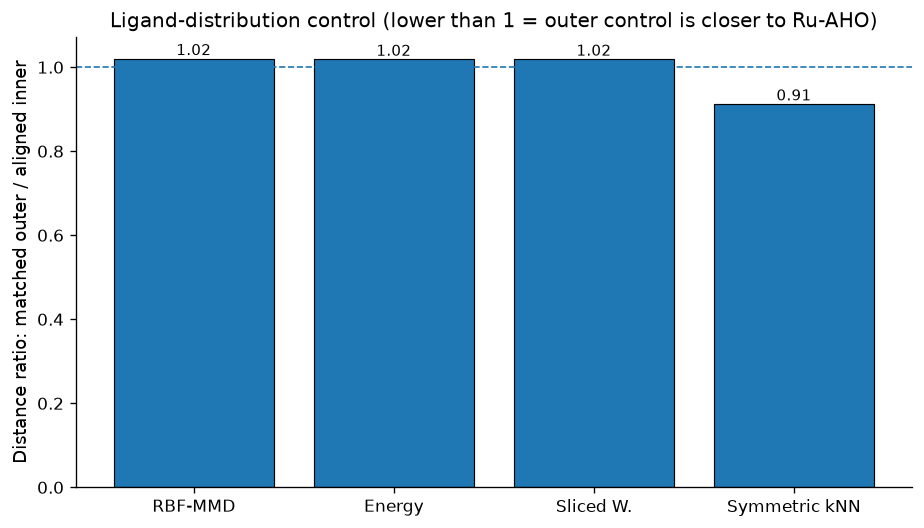

,source,n_reactions,n_substrates,n_ligands,substrate_rbf_mmd,substrate_energy_distance,substrate_sliced_wasserstein,substrate_symmetric_knn_distance,pressure_norm_wasserstein,temperature_norm_wasserstein,sc_norm_wasserstein,solvent_tv,additive_tv,ddG_wasserstein_kcal_mol,ddG_median
0,aligned_inner,495,214,41,0.4255,4.9039,0.6494,11.1530,0.3610,0.4908,0.0946,0.5150,0.6363,0.1783,2.1324
1,ligand_matched_outer,495,194,44,0.4467,5.4267,0.7059,11.5853,0.3975,0.2285,0.2882,0.7173,0.7781,0.1294,1.9651


In [7]:
# Recalculate ligand metrics on the actual frozen row subset.
SELECTED_OUTER_LIGAND_METRICS = ligand_distribution_metrics(
    unique_valid_smiles(SELECTED_OUTER_DF, "Ligand SMILES")
)

ligand_audit_rows = []
for metric in METRIC_NAMES:
    aligned = float(INNER_LIGAND_METRICS[metric])
    selected = float(SELECTED_OUTER_LIGAND_METRICS[metric])
    ligand_audit_rows.append({
        "metric": metric,
        "aligned_inner_to_target": aligned,
        "ligand_matched_outer_to_target": selected,
        "outer_over_aligned_ratio": selected / aligned,
        "outer_is_closer": bool(selected < aligned),
    })
LIGAND_AUDIT_DF = pd.DataFrame(ligand_audit_rows)
LIGAND_AUDIT_DF.to_csv(LIGAND_AUDIT_PATH, index=False)
display(LIGAND_AUDIT_DF.round(4))

STRICT_LIGAND_MATCH = bool(LIGAND_AUDIT_DF["outer_is_closer"].all())
print("STRICT_LIGAND_MATCH (all four distances lower):", STRICT_LIGAND_MATCH)

fig, ax = plt.subplots(figsize=(7.8, 4.5))
ratios = LIGAND_AUDIT_DF["outer_over_aligned_ratio"].to_numpy(dtype=float)
x = np.arange(len(ratios))
ax.bar(x, ratios, edgecolor="black", linewidth=0.7)
ax.axhline(1.0, linestyle="--", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(["RBF-MMD", "Energy", "Sliced W.", "Symmetric kNN"])
ax.set_ylabel("Distance ratio: matched outer / aligned inner")
ax.set_title("Ligand-distribution control (lower than 1 = outer control is closer to Ru-AHO)")
for i, value in enumerate(ratios):
    ax.text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "ligand_distribution_match_ratios.svg", bbox_inches="tight")
plt.show()

# ---- post-hoc non-selection audit ----

def normalized_wasserstein(source: pd.Series, target: pd.Series) -> float:
    a = pd.to_numeric(source, errors="coerce").dropna().to_numpy(dtype=float)
    b = pd.to_numeric(target, errors="coerce").dropna().to_numpy(dtype=float)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    pooled = np.concatenate([a, b])
    q1, q3 = np.quantile(pooled, [0.25, 0.75])
    scale = max(float(q3 - q1), float(np.std(pooled)), 1e-6)
    return float(wasserstein_distance(a, b) / scale)


def categorical_tv(source: pd.Series, target: pd.Series) -> float:
    a = source.fillna("<MISSING>").astype(str).replace("", "<MISSING>")
    b = target.fillna("<MISSING>").astype(str).replace("", "<MISSING>")
    cats = sorted(set(a.unique()) | set(b.unique()))
    pa = a.value_counts(normalize=True).reindex(cats, fill_value=0.0).to_numpy()
    pb = b.value_counts(normalize=True).reindex(cats, fill_value=0.0).to_numpy()
    return float(0.5 * np.abs(pa - pb).sum())


def build_shared_structure_space(smiles_lists: list[list[str]]):
    union = sorted(set().union(*[set(x) for x in smiles_lists]))
    raw = np.vstack([maccs_vector(s) for s in union])
    variable = raw.var(axis=0) > 0
    scaled = StandardScaler().fit_transform(raw[:, variable]).astype(np.float32)
    row = {s: scaled[i] for i, s in enumerate(union)}
    d = pairwise_distances(scaled)
    vals = d[np.triu_indices_from(d, k=1)]
    vals = vals[np.isfinite(vals) & (vals > 0)]
    med = float(np.median(vals)) if len(vals) else 1.0
    gamma = 1.0 / (2.0 * med**2 + 1e-12)
    rng = np.random.default_rng(RANDOM_STATE)
    directions = rng.normal(size=(SLICED_PROJECTIONS, scaled.shape[1]))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    return row, gamma, directions


def structure_metrics_three(source_df, target_df, col, shared_row, gamma, directions):
    src = unique_valid_smiles(source_df, col)
    tgt = unique_valid_smiles(target_df, col)
    X = np.vstack([shared_row[s] for s in src]).astype(np.float32)
    Y = np.vstack([shared_row[s] for s in tgt]).astype(np.float32)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    mmd = np.sqrt(max(float(Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()), 0.0))
    energy = max(float(2 * pairwise_distances(X, Y).mean() - pairwise_distances(X, X).mean() - pairwise_distances(Y, Y).mean()), 0.0)
    px, py = X @ directions.T, Y @ directions.T
    q = np.linspace(0, 1, SLICED_QUANTILES)
    sw = float(np.mean(np.abs(np.quantile(px, q, axis=0) - np.quantile(py, q, axis=0))))
    Dxy = pairwise_distances(X, Y)
    knn = 0.5 * (
        _median_mean_knn_from_distance_block(Dxy, KNN_K)
        + _median_mean_knn_from_distance_block(Dxy.T, KNN_K)
    )
    return {"rbf_mmd": mmd, "energy_distance": energy, "sliced_wasserstein": sw, "symmetric_knn_distance": knn}

substrate_lists = [
    unique_valid_smiles(INNER_DF, "Reactant SMILES"),
    unique_valid_smiles(OUTER_DF, "Reactant SMILES"),
    unique_valid_smiles(TARGET_DF, "Reactant SMILES"),
]
substrate_row, substrate_gamma, substrate_dirs = build_shared_structure_space(substrate_lists)

posthoc_rows = []
for label, source_df in [
    ("aligned_inner", INNER_DF),
    ("ligand_matched_outer", SELECTED_OUTER_DF),
]:
    sub_metrics = structure_metrics_three(
        source_df, TARGET_DF, "Reactant SMILES", substrate_row, substrate_gamma, substrate_dirs
    )
    row = {
        "source": label,
        "n_reactions": len(source_df),
        "n_substrates": source_df["Reactant SMILES"].nunique(),
        "n_ligands": source_df["Ligand SMILES"].nunique(),
        **{f"substrate_{k}": v for k, v in sub_metrics.items()},
        "pressure_norm_wasserstein": normalized_wasserstein(source_df["Pressure/atm"], TARGET_DF["Pressure/atm"]),
        "temperature_norm_wasserstein": normalized_wasserstein(source_df["Temperature/C"], TARGET_DF["Temperature/C"]),
        "sc_norm_wasserstein": normalized_wasserstein(source_df["S/C"], TARGET_DF["S/C"]),
        "solvent_tv": categorical_tv(source_df["Solvent SMILES"], TARGET_DF["Solvent SMILES"]),
        "additive_tv": categorical_tv(source_df["Additive SMILES"], TARGET_DF["Additive SMILES"]),
        "ddG_wasserstein_kcal_mol": float(wasserstein_distance(source_df[TARGET_COLUMN], TARGET_DF[TARGET_COLUMN])),
        "ddG_median": float(source_df[TARGET_COLUMN].median()),
    }
    posthoc_rows.append(row)

POSTHOC_DF = pd.DataFrame(posthoc_rows)
POSTHOC_DF.to_csv(POSTHOC_AUDIT_PATH, index=False)
display(POSTHOC_DF.round(4))


## 5. Build the same MACCS and SPOC representations used in the main transfer notebooks

The feature caches are local to this S2 directory and are keyed to the current cleaned domains, preventing stale pre-reannotation feature matrices from being reused accidentally.

In [8]:
# ------------------------- MACCS -------------------------
MACCS_LENGTH = 167
MACCS_COMPONENT_COLUMNS = COMPONENT_COLS


def build_maccs_vector_pm1(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) and smiles.strip() else None
    arr = np.zeros(MACCS_LENGTH, dtype=np.float32)
    if mol is not None:
        fp = MACCSkeys.GenMACCSKeys(mol)
        ConvertToNumpyArray(fp, arr)
    return arr * 2.0 - 1.0


def build_maccs_feature_matrix(df: pd.DataFrame, cache: dict) -> np.ndarray:
    rows = []
    for _, row in df.iterrows():
        pieces = []
        for col in MACCS_COMPONENT_COLUMNS:
            smi = row[col] if pd.notna(row[col]) else ""
            if smi not in cache:
                cache[smi] = build_maccs_vector_pm1(smi)
            pieces.append(cache[smi])
        rows.append(np.concatenate(pieces))
    x_struct = np.asarray(rows, dtype=np.float32)
    x_cond = df[CONDITION_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=np.float32)
    return np.concatenate([x_struct, x_cond], axis=1).astype(np.float32)


def domain_slices():
    result = {}
    start = 0
    for key, df in DOMAINS.items():
        stop = start + len(df)
        result[key] = slice(start, stop)
        start = stop
    return result


def load_feature_cache(matrix_path: Path, meta_path: Path, expected_rows: int):
    if FORCE_RECOMPUTE_FEATURES or not matrix_path.exists() or not meta_path.exists():
        return None
    try:
        meta = json.loads(meta_path.read_text())
        matrix = np.load(matrix_path)
        if meta.get("data_hash") == DATA_HASH and matrix.shape[0] == expected_rows:
            print("Loaded feature cache:", matrix_path)
            return matrix.astype(np.float32, copy=False)
    except Exception:
        return None
    return None


def save_feature_cache(matrix, matrix_path, meta_path, representation):
    np.save(matrix_path, matrix)
    meta_path.write_text(json.dumps({"data_hash": DATA_HASH, "representation": representation, "shape": list(matrix.shape)}, indent=2))

ALL_DF = pd.concat(DOMAINS.values(), ignore_index=True)
EXPECTED_ROWS = len(ALL_DF)

MACCS_CACHE = FEATURE_CACHE_DIR / "maccs_feature_matrix.npy"
MACCS_META = FEATURE_CACHE_DIR / "maccs_feature_matrix.json"
MACCS_MATRIX = load_feature_cache(MACCS_CACHE, MACCS_META, EXPECTED_ROWS)
if MACCS_MATRIX is None:
    print("Building MACCS features...")
    cache = {}
    MACCS_MATRIX = np.vstack([build_maccs_feature_matrix(df, cache) for df in DOMAINS.values()])
    save_feature_cache(MACCS_MATRIX, MACCS_CACHE, MACCS_META, "MACCS")

MACCS_FEATURES = OrderedDict((key, MACCS_MATRIX[sl]) for key, sl in domain_slices().items())
print("MACCS shapes:", {k: v.shape for k, v in MACCS_FEATURES.items()})

# ------------------------- SPOC-like representation used in 1_2 -------------------------
DESC_LIST = list(Descriptors._descList)
DESC_NAMES = [name for name, _ in DESC_LIST]


def smiles_to_mol(smiles: str):
    if smiles is None or not str(smiles).strip():
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def component_spoc_matrix(df: pd.DataFrame, col: str) -> np.ndarray:
    maccs_rows = []
    desc_rows = []
    for smi in df[col].astype(str):
        mol = smiles_to_mol(smi)
        marr = np.zeros(MACCS_LENGTH, dtype=np.float32)
        if mol is not None:
            try:
                ConvertToNumpyArray(MACCSkeys.GenMACCSKeys(mol), marr)
            except Exception:
                marr[:] = np.nan
        maccs_rows.append(marr)

        vals = []
        for _, fn in DESC_LIST:
            if mol is None:
                vals.append(np.nan)
            else:
                try:
                    vals.append(float(fn(mol)))
                except Exception:
                    vals.append(np.nan)
        desc_rows.append(vals)
    return np.concatenate([np.asarray(maccs_rows, dtype=np.float32), np.asarray(desc_rows, dtype=np.float32)], axis=1)


def build_spoc_matrix(df: pd.DataFrame) -> np.ndarray:
    pieces = [component_spoc_matrix(df, col) for col in COMPONENT_COLS]
    pieces.append(df[CONDITION_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32))
    label_df = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["Metal", "Solvent", "Additive"],
        dtype=np.float32,
    )
    pieces.append(label_df.to_numpy(dtype=np.float32))
    return np.concatenate(pieces, axis=1).astype(np.float32)

SPOC_CACHE = FEATURE_CACHE_DIR / "spoc_feature_matrix.npy"
SPOC_META = FEATURE_CACHE_DIR / "spoc_feature_matrix.json"
SPOC_MATRIX = load_feature_cache(SPOC_CACHE, SPOC_META, EXPECTED_ROWS)
if SPOC_MATRIX is None:
    print("Building SPOC features...")
    SPOC_MATRIX = build_spoc_matrix(ALL_DF)
    save_feature_cache(SPOC_MATRIX, SPOC_CACHE, SPOC_META, "SPOC")

SPOC_FEATURES = OrderedDict((key, SPOC_MATRIX[sl]) for key, sl in domain_slices().items())
print("SPOC shapes:", {k: v.shape for k, v in SPOC_FEATURES.items()})


Building MACCS features...
MACCS shapes: {'ru_ahk_inner': (495, 838), 'ru_ahk_outer': (1539, 838), 'ru_aho_inner': (98, 838)}
Building SPOC features...
SPOC shapes: {'ru_ahk_inner': (495, 2043), 'ru_ahk_outer': (1539, 2043), 'ru_aho_inner': (98, 2043)}


## 6. Fixed target splits and classical model pool

In [9]:
TARGET_SPLITS = list(
    KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE).split(np.arange(len(TARGET_DF)))
)

MACCS_MODEL_FACTORIES = OrderedDict([
    ("AdaBoostRegressor", lambda: AdaBoostRegressor(random_state=RANDOM_STATE)),
    ("ExtraTreesRegressor", lambda: ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE)),
    ("GradientBoostingRegressor", lambda: GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ("HistGradientBoostingRegressor", lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    ("RandomForestRegressor", lambda: RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)),
    ("GaussianProcessRegressor", lambda: make_pipeline(StandardScaler(), GaussianProcessRegressor(normalize_y=True, alpha=1e-6, random_state=RANDOM_STATE))),
    ("KNeighborsRegressor", lambda: make_pipeline(StandardScaler(), KNeighborsRegressor())),
    ("SVR", lambda: make_pipeline(StandardScaler(), SVR())),
    ("LinearSVR", lambda: make_pipeline(StandardScaler(), LinearSVR(random_state=RANDOM_STATE, max_iter=5000))),
    ("DecisionTreeRegressor", lambda: DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ("ExtraTreeRegressor", lambda: ExtraTreeRegressor(random_state=RANDOM_STATE)),
])

SPOC_MODEL_FACTORIES = OrderedDict([
    ("AdaBoostRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), AdaBoostRegressor(random_state=RANDOM_STATE))),
    ("ExtraTreesRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE))),
    ("GradientBoostingRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), GradientBoostingRegressor(random_state=RANDOM_STATE))),
    ("HistGradientBoostingRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), HistGradientBoostingRegressor(random_state=RANDOM_STATE))),
    ("RandomForestRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE))),
    ("GaussianProcessRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), GaussianProcessRegressor(normalize_y=True, alpha=1e-6, random_state=RANDOM_STATE))),
    ("KNeighborsRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), KNeighborsRegressor())),
    ("SVR", lambda: make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), SVR())),
    ("LinearSVR", lambda: make_pipeline(SimpleImputer(strategy="mean"), StandardScaler(), LinearSVR(random_state=RANDOM_STATE, max_iter=5000))),
    ("DecisionTreeRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), DecisionTreeRegressor(random_state=RANDOM_STATE))),
    ("ExtraTreeRegressor", lambda: make_pipeline(SimpleImputer(strategy="mean"), ExtraTreeRegressor(random_state=RANDOM_STATE))),
])

MODEL_KEYS = list(MACCS_MODEL_FACTORIES.keys())
assert MODEL_KEYS == list(SPOC_MODEL_FACTORIES.keys())

display(pd.DataFrame({"model": MODEL_KEYS}))
print("Target fold sizes:", [(len(tr), len(te)) for tr, te in TARGET_SPLITS])


,model
0,AdaBoostRegressor
1,ExtraTreesRegressor
2,GradientBoostingRegressor
3,HistGradientBoostingRegressor
4,RandomForestRegressor
5,GaussianProcessRegressor
6,KNeighborsRegressor
7,SVR
8,LinearSVR
9,DecisionTreeRegressor


Target fold sizes: [(78, 20), (78, 20), (78, 20), (79, 19), (79, 19)]


## 7. Pooled OOF benchmark

Three scenes are evaluated:

- **Target-only:** Ru-AHO training fold only;
- **Mechanism-aligned:** all inner-sphere Ru-AHK reactions ($N$ reactions);
- **Ligand-distribution-matched mechanism-mismatched:** the frozen outer-sphere subset selected above (also $N$ reactions).

For both source scenes, mixed transfer and delta learning are evaluated. The source subsets remain fixed across all five target folds.

In [10]:
OOF_COLUMNS = [
    "descriptor", "model", "source_domain", "method_label", "fold_id", "target_index",
    "y_true", "y_pred", "data_hash", "outer_subset_hash", "strict_ligand_match", "source_size",
]


def predict_1d(model, x):
    return np.asarray(model.predict(x), dtype=float).reshape(-1)


def run_descriptor_benchmark(descriptor_name, features, model_factories):
    rows = []
    x_inner = features["ru_ahk_inner"]
    x_outer = features["ru_ahk_outer"][SELECTED_OUTER_ROWS]
    x_target = features["ru_aho_inner"]
    y_inner = INNER_DF[TARGET_COLUMN].to_numpy(dtype=float)
    y_outer = OUTER_DF[TARGET_COLUMN].to_numpy(dtype=float)[SELECTED_OUTER_ROWS]
    y_target = TARGET_DF[TARGET_COLUMN].to_numpy(dtype=float)

    for model_key in MODEL_KEYS:
        print(f"{descriptor_name}: {model_key}")
        factory = model_factories[model_key]

        for fold_id, (train_idx, test_idx) in enumerate(TARGET_SPLITS, start=1):
            x_t_train, x_t_test = x_target[train_idx], x_target[test_idx]
            y_t_train, y_t_test = y_target[train_idx], y_target[test_idx]

            # Target-only
            model = factory()
            model.fit(x_t_train, y_t_train)
            pred = predict_1d(model, x_t_test)
            for local_idx, yt, yp in zip(test_idx, y_t_test, pred):
                rows.append({
                    "descriptor": descriptor_name, "model": model_key,
                    "source_domain": "target_only", "method_label": "Target-only",
                    "fold_id": fold_id, "target_index": int(local_idx),
                    "y_true": float(yt), "y_pred": float(yp),
                    "data_hash": DATA_HASH, "outer_subset_hash": subset_hash,
                    "strict_ligand_match": STRICT_LIGAND_MATCH, "source_size": SOURCE_SIZE,
                })

            for source_domain, x_source, y_source in [
                ("mechanism_aligned_inner", x_inner, y_inner),
                ("ligand_matched_outer", x_outer, y_outer),
            ]:
                mixed = factory()
                mixed.fit(np.vstack([x_source, x_t_train]), np.concatenate([y_source, y_t_train]))
                pred_mixed = predict_1d(mixed, x_t_test)

                source_model = factory()
                source_model.fit(x_source, y_source)
                source_train_pred = predict_1d(source_model, x_t_train)
                delta = factory()
                delta.fit(x_t_train, y_t_train - source_train_pred)
                pred_delta = predict_1d(source_model, x_t_test) + predict_1d(delta, x_t_test)

                for method_label, values in [("Mixed transfer", pred_mixed), ("Delta learning", pred_delta)]:
                    for local_idx, yt, yp in zip(test_idx, y_t_test, values):
                        rows.append({
                            "descriptor": descriptor_name, "model": model_key,
                            "source_domain": source_domain, "method_label": method_label,
                            "fold_id": fold_id, "target_index": int(local_idx),
                            "y_true": float(yt), "y_pred": float(yp),
                            "data_hash": DATA_HASH, "outer_subset_hash": subset_hash,
                            "strict_ligand_match": STRICT_LIGAND_MATCH, "source_size": SOURCE_SIZE,
                        })
    return rows


def valid_cached_oof(path: Path) -> pd.DataFrame | None:
    if FORCE_RECOMPUTE_RESULTS or not path.exists() or path.stat().st_size == 0:
        return None
    try:
        df = pd.read_csv(path)
    except EmptyDataError:
        return None
    required = set(OOF_COLUMNS)
    if not required.issubset(df.columns):
        return None
    if set(df["data_hash"].astype(str).unique()) != {DATA_HASH}:
        return None
    if set(df["outer_subset_hash"].astype(str).unique()) != {subset_hash}:
        return None
    return df

OOF_DF = valid_cached_oof(OOF_PATH)
if OOF_DF is None:
    rows = []
    rows.extend(run_descriptor_benchmark("MACCS", MACCS_FEATURES, MACCS_MODEL_FACTORIES))
    rows.extend(run_descriptor_benchmark("SPOC", SPOC_FEATURES, SPOC_MODEL_FACTORIES))
    OOF_DF = pd.DataFrame(rows, columns=OOF_COLUMNS)
    OOF_DF.to_csv(OOF_PATH, index=False)
else:
    print("Loaded current OOF cache:", OOF_PATH)

print("OOF rows:", len(OOF_DF))
display(OOF_DF.head())


MACCS: AdaBoostRegressor
MACCS: ExtraTreesRegressor
MACCS: GradientBoostingRegressor
MACCS: HistGradientBoostingRegressor
MACCS: RandomForestRegressor
MACCS: GaussianProcessRegressor
MACCS: KNeighborsRegressor
MACCS: SVR
MACCS: LinearSVR
MACCS: DecisionTreeRegressor
MACCS: ExtraTreeRegressor
SPOC: AdaBoostRegressor
SPOC: ExtraTreesRegressor
SPOC: GradientBoostingRegressor
SPOC: HistGradientBoostingRegressor
SPOC: RandomForestRegressor
SPOC: GaussianProcessRegressor
SPOC: KNeighborsRegressor
SPOC: SVR
SPOC: LinearSVR
SPOC: DecisionTreeRegressor
SPOC: ExtraTreeRegressor
OOF rows: 10780


,descriptor,model,source_domain,method_label,fold_id,target_index,y_true,y_pred,data_hash,outer_subset_hash,strict_ligand_match,source_size
0,MACCS,AdaBoostRegressor,target_only,Target-only,1,0,4.500500,2.427915,0155839dd5fe4717,9dec186e2c6c7767,False,495
1,MACCS,AdaBoostRegressor,target_only,Target-only,1,4,3.134376,3.030003,0155839dd5fe4717,9dec186e2c6c7767,False,495
2,MACCS,AdaBoostRegressor,target_only,Target-only,1,10,2.892794,2.413408,0155839dd5fe4717,9dec186e2c6c7767,False,495
3,MACCS,AdaBoostRegressor,target_only,Target-only,1,12,2.720953,2.413408,0155839dd5fe4717,9dec186e2c6c7767,False,495
4,MACCS,AdaBoostRegressor,target_only,Target-only,1,18,2.720953,2.527697,0155839dd5fe4717,9dec186e2c6c7767,False,495


## 8. Results: model-wise and best-outcome comparisons

In [11]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[finite], y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }

GROUP_COLS = ["descriptor", "model", "source_domain", "method_label"]
score_rows = []
for keys, group in OOF_DF.groupby(GROUP_COLS, dropna=False):
    row = dict(zip(GROUP_COLS, keys))
    row.update(pooled_metrics(group["y_true"], group["y_pred"]))
    score_rows.append(row)
SCORE_DF = pd.DataFrame(score_rows)
SCORE_DF.to_csv(SCORE_PATH, index=False)
display(SCORE_DF.sort_values(["descriptor", "R2"], ascending=[True, False]))

# Same-model, same-transfer-method paired comparison of aligned vs ligand-matched outer.
paired_rows = []
for descriptor in ["MACCS", "SPOC"]:
    for model in MODEL_KEYS:
        for method in ["Mixed transfer", "Delta learning"]:
            aligned = SCORE_DF.loc[
                SCORE_DF["descriptor"].eq(descriptor)
                & SCORE_DF["model"].eq(model)
                & SCORE_DF["source_domain"].eq("mechanism_aligned_inner")
                & SCORE_DF["method_label"].eq(method)
            ]
            outer = SCORE_DF.loc[
                SCORE_DF["descriptor"].eq(descriptor)
                & SCORE_DF["model"].eq(model)
                & SCORE_DF["source_domain"].eq("ligand_matched_outer")
                & SCORE_DF["method_label"].eq(method)
            ]
            if len(aligned) == 1 and len(outer) == 1:
                a, o = aligned.iloc[0], outer.iloc[0]
                paired_rows.append({
                    "descriptor": descriptor,
                    "model": model,
                    "method_label": method,
                    "aligned_R2": a["R2"],
                    "ligand_matched_outer_R2": o["R2"],
                    "delta_R2_aligned_minus_outer": a["R2"] - o["R2"],
                    "aligned_MAE": a["MAE"],
                    "ligand_matched_outer_MAE": o["MAE"],
                    "aligned_better_R2": bool(a["R2"] > o["R2"]),
                    "aligned_better_MAE": bool(a["MAE"] < o["MAE"]),
                })
PAIRED_DF = pd.DataFrame(paired_rows)
PAIRED_DF.to_csv(PAIRWISE_PATH, index=False)
display(PAIRED_DF)

modelwise_summary = (
    PAIRED_DF.groupby(["descriptor", "method_label"], as_index=False)
    .agg(
        n_models=("model", "size"),
        n_aligned_better_R2=("aligned_better_R2", "sum"),
        median_delta_R2=("delta_R2_aligned_minus_outer", "median"),
        n_aligned_better_MAE=("aligned_better_MAE", "sum"),
    )
)
print("Model-wise paired summary")
display(modelwise_summary)

# Best pooled OOF result within each scene, following the main-text reporting convention.
best_rows = []
for descriptor in ["MACCS", "SPOC"]:
    descriptor_df = SCORE_DF.loc[SCORE_DF["descriptor"].eq(descriptor)]
    for scene, label in [
        ("target_only", "Target-only"),
        ("mechanism_aligned_inner", "Mechanism-aligned inner"),
        ("ligand_matched_outer", "Ligand-matched outer"),
    ]:
        sub = descriptor_df.loc[descriptor_df["source_domain"].eq(scene)]
        if scene != "target_only":
            sub = sub.loc[sub["method_label"].isin(["Mixed transfer", "Delta learning"])]
        row = sub.sort_values("R2", ascending=False).iloc[0].copy()
        best_rows.append({
            "descriptor": descriptor,
            "scene": label,
            "model": row["model"],
            "method": row["method_label"],
            "R2": row["R2"],
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
        })
BEST_DF = pd.DataFrame(best_rows)
BEST_DF.to_csv(BEST_PATH, index=False)
print("Best pooled OOF outcomes")
display(BEST_DF)

# Compact direct answer table.
verdict_rows = []
for descriptor in ["MACCS", "SPOC"]:
    b = BEST_DF.loc[BEST_DF["descriptor"].eq(descriptor)].set_index("scene")
    verdict_rows.append({
        "descriptor": descriptor,
        "target_only_R2": float(b.loc["Target-only", "R2"]),
        "aligned_R2": float(b.loc["Mechanism-aligned inner", "R2"]),
        "ligand_matched_outer_R2": float(b.loc["Ligand-matched outer", "R2"]),
        "aligned_minus_outer_R2": float(b.loc["Mechanism-aligned inner", "R2"] - b.loc["Ligand-matched outer", "R2"]),
        "aligned_beats_ligand_matched_outer": bool(b.loc["Mechanism-aligned inner", "R2"] > b.loc["Ligand-matched outer", "R2"]),
    })
VERDICT_DF = pd.DataFrame(verdict_rows)
print("Key S2 result")
display(VERDICT_DF)


,descriptor,model,source_domain,method_label,R2,MAE,RMSE,n_test_total
10,MACCS,ExtraTreeRegressor,ligand_matched_outer,Delta learning,0.639170,0.374976,0.568086,98
18,MACCS,ExtraTreesRegressor,mechanism_aligned_inner,Mixed transfer,0.635444,0.354045,0.571012,98
33,MACCS,HistGradientBoostingRegressor,mechanism_aligned_inner,Mixed transfer,0.632340,0.413336,0.573437,98
15,MACCS,ExtraTreesRegressor,ligand_matched_outer,Delta learning,0.625833,0.402977,0.578489,98
28,MACCS,GradientBoostingRegressor,mechanism_aligned_inner,Mixed transfer,0.615059,0.421068,0.586760,98
...,...,...,...,...,...,...,...,...
99,SPOC,LinearSVR,target_only,Target-only,-0.205305,0.723546,1.038273,98
60,SPOC,DecisionTreeRegressor,ligand_matched_outer,Delta learning,-0.560329,0.665872,1.181329,98
96,SPOC,LinearSVR,ligand_matched_outer,Mixed transfer,-0.700483,0.722708,1.233244,98
97,SPOC,LinearSVR,mechanism_aligned_inner,Delta learning,-0.913007,0.840790,1.308040,98


,descriptor,model,method_label,aligned_R2,ligand_matched_outer_R2,delta_R2_aligned_minus_outer,aligned_MAE,ligand_matched_outer_MAE,aligned_better_R2,aligned_better_MAE
0,MACCS,AdaBoostRegressor,Mixed transfer,0.349187,0.422201,-7.301357e-02,0.553698,0.530825,False,False
1,MACCS,AdaBoostRegressor,Delta learning,0.371441,0.336956,3.448550e-02,0.505526,0.533929,True,True
2,MACCS,ExtraTreesRegressor,Mixed transfer,0.635444,0.490062,1.453814e-01,0.354045,0.408017,True,True
3,MACCS,ExtraTreesRegressor,Delta learning,0.447223,0.625833,-1.786108e-01,0.468681,0.402977,False,False
4,MACCS,GradientBoostingRegressor,Mixed transfer,0.615059,0.537595,7.746357e-02,0.421068,0.450709,True,True
5,MACCS,GradientBoostingRegressor,Delta learning,0.576832,0.441590,1.352416e-01,0.408656,0.447782,True,True
6,MACCS,HistGradientBoostingRegressor,Mixed transfer,0.632340,0.574429,5.791158e-02,0.413336,0.441754,True,True
7,MACCS,HistGradientBoostingRegressor,Delta learning,0.604966,0.273921,3.310444e-01,0.434337,0.511316,True,True
8,MACCS,RandomForestRegressor,Mixed transfer,0.613706,0.518346,9.535941e-02,0.419966,0.457760,True,True
9,MACCS,RandomForestRegressor,Delta learning,0.555452,0.392530,1.629223e-01,0.428680,0.464103,True,True


Model-wise paired summary


,descriptor,method_label,n_models,n_aligned_better_R2,median_delta_R2,n_aligned_better_MAE
0,MACCS,Delta learning,11,7,0.034486,7
1,MACCS,Mixed transfer,11,7,0.072366,7
2,SPOC,Delta learning,11,9,0.179983,9
3,SPOC,Mixed transfer,11,7,0.049236,7


Best pooled OOF outcomes


,descriptor,scene,model,method,R2,MAE,RMSE
0,MACCS,Target-only,SVR,Target-only,0.495043,0.452117,0.672032
1,MACCS,Mechanism-aligned inner,ExtraTreesRegressor,Mixed transfer,0.635444,0.354045,0.571012
2,MACCS,Ligand-matched outer,ExtraTreeRegressor,Delta learning,0.639170,0.374976,0.568086
3,SPOC,Target-only,GradientBoostingRegressor,Target-only,0.621655,0.405804,0.581710
4,SPOC,Mechanism-aligned inner,AdaBoostRegressor,Delta learning,0.717798,0.371704,0.502392
5,SPOC,Ligand-matched outer,AdaBoostRegressor,Delta learning,0.597815,0.432445,0.599757


Key S2 result


,descriptor,target_only_R2,aligned_R2,ligand_matched_outer_R2,aligned_minus_outer_R2,aligned_beats_ligand_matched_outer
0,MACCS,0.495043,0.635444,0.639170,-0.003726,False
1,SPOC,0.621655,0.717798,0.597815,0.119983,True


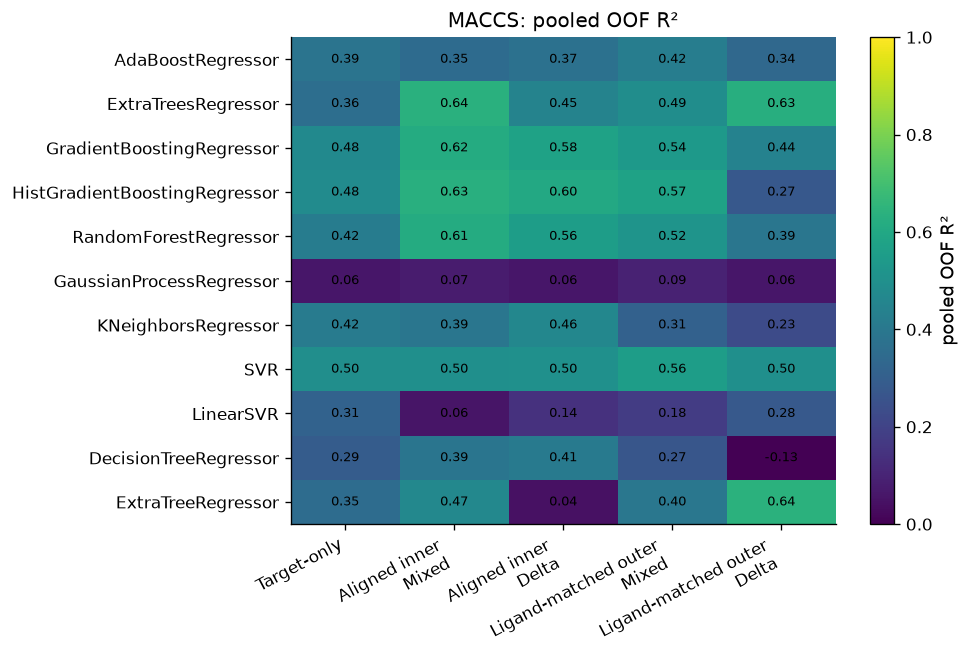

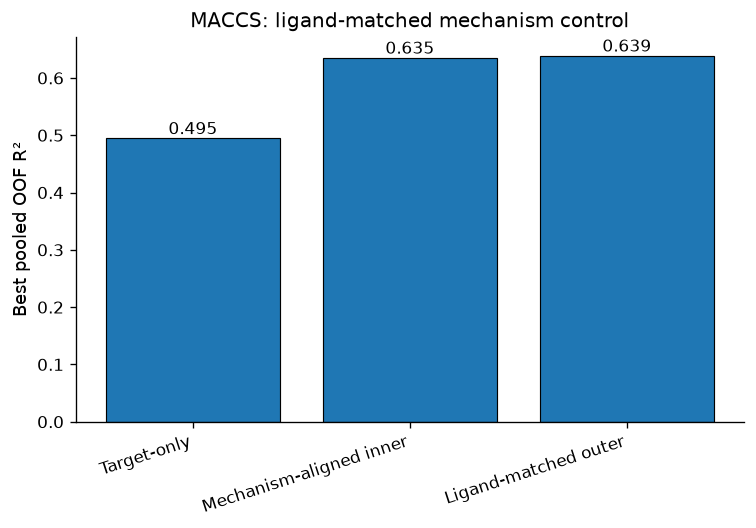

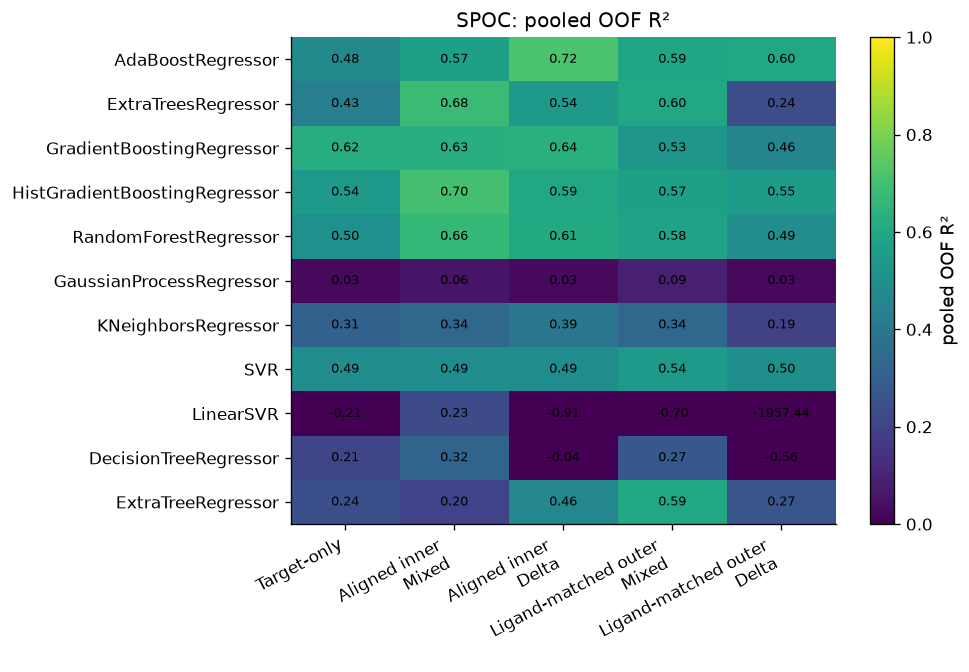

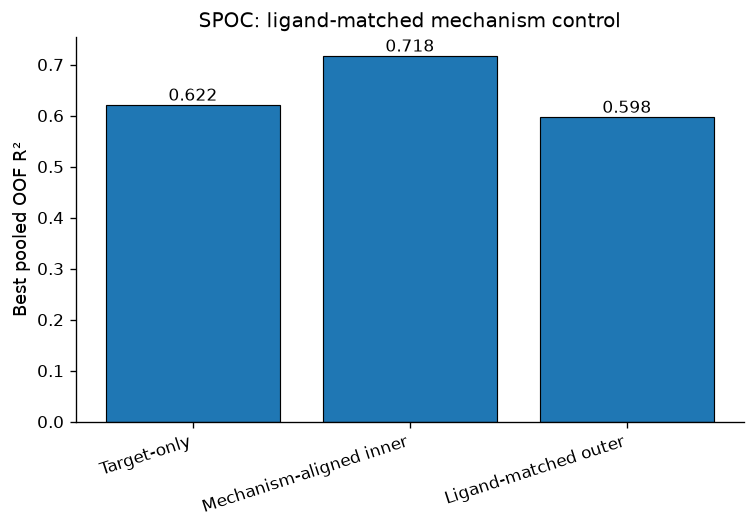

In [12]:
# Publication-facing heatmaps and compact best-result bar charts.
def heatmap_label(row):
    if row["source_domain"] == "target_only":
        return "Target-only"
    source = "Aligned inner" if row["source_domain"] == "mechanism_aligned_inner" else "Ligand-matched outer"
    method = "Mixed" if row["method_label"] == "Mixed transfer" else "Delta"
    return f"{source}\n{method}"

column_order = [
    "Target-only",
    "Aligned inner\nMixed",
    "Aligned inner\nDelta",
    "Ligand-matched outer\nMixed",
    "Ligand-matched outer\nDelta",
]

for descriptor in ["MACCS", "SPOC"]:
    sub = SCORE_DF.loc[SCORE_DF["descriptor"].eq(descriptor)].copy()
    sub["plot_col"] = sub.apply(heatmap_label, axis=1)
    table = sub.pivot_table(index="model", columns="plot_col", values="R2", aggfunc="first").reindex(index=MODEL_KEYS, columns=column_order)
    table.to_csv(TABLE_DIR / f"{descriptor.lower()}_r2_heatmap.csv")

    fig, ax = plt.subplots(figsize=(8.3, 5.7))
    values = table.to_numpy(dtype=float)
    im = ax.imshow(np.ma.masked_invalid(np.clip(values, 0, 1)), aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns, rotation=28, ha="right")
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_title(f"{descriptor}: pooled OOF R²")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="pooled OOF R²")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{descriptor.lower()}_r2_heatmap.svg", bbox_inches="tight")
    plt.show()

    b = BEST_DF.loc[BEST_DF["descriptor"].eq(descriptor)].copy()
    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    x = np.arange(len(b))
    bars = ax.bar(x, b["R2"].to_numpy(), edgecolor="black", linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(b["scene"], rotation=18, ha="right")
    ax.set_ylabel("Best pooled OOF R²")
    ax.set_title(f"{descriptor}: ligand-matched mechanism control")
    for bar, value in zip(bars, b["R2"].to_numpy()):
        ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{descriptor.lower()}_best_result_bar.svg", bbox_inches="tight")
    plt.show()


In [13]:
print("=" * 72)
print("S2 BOTTOM LINE")
print("=" * 72)
print(f"Equal source size: {SOURCE_SIZE} reactions vs {SOURCE_SIZE} reactions")
print(f"Strict four-metric ligand match achieved: {STRICT_LIGAND_MATCH}")
print("Ligand-distance ratios (matched outer / aligned inner; <1 means outer is closer):")
for _, row in LIGAND_AUDIT_DF.iterrows():
    print(f"  {row['metric']}: {row['outer_over_aligned_ratio']:.3f}")
print()
for _, row in VERDICT_DF.iterrows():
    print(
        f"{row['descriptor']}: target-only R2={row['target_only_R2']:.3f}; "
        f"aligned R2={row['aligned_R2']:.3f}; "
        f"ligand-matched outer R2={row['ligand_matched_outer_R2']:.3f}; "
        f"aligned - outer={row['aligned_minus_outer_R2']:+.3f}"
    )

both_descriptors = bool(VERDICT_DF["aligned_beats_ligand_matched_outer"].all())
print()
if STRICT_LIGAND_MATCH and both_descriptors:
    print(
        "RESULT: The mismatched outer control is closer to Ru-AHO in ligand space on all four "
        "distribution metrics, yet mechanism-aligned transfer still gives the higher best pooled OOF R2 "
        "in both representations. This is the strongest S2 outcome."
    )
elif both_descriptors:
    print(
        "RESULT: Mechanism-aligned transfer still gives the higher best pooled OOF R2 in both representations, "
        "but the outer control did not beat the aligned source on every ligand-distance metric. Interpret the "
        "specific reversed ligand metrics rather than claiming uniform ligand-space matching."
    )
else:
    print(
        "RESULT: After ligand-distribution matching, the aligned source does not retain a best-R2 advantage in "
        "both representations. Inspect the full model-wise table before making a mechanism-specific claim."
    )


S2 BOTTOM LINE
Equal source size: 495 reactions vs 495 reactions
Strict four-metric ligand match achieved: False
Ligand-distance ratios (matched outer / aligned inner; <1 means outer is closer):
  rbf_mmd: 1.020
  energy_distance: 1.019
  sliced_wasserstein: 1.019
  symmetric_knn_distance: 0.912

MACCS: target-only R2=0.495; aligned R2=0.635; ligand-matched outer R2=0.639; aligned - outer=-0.004
SPOC: target-only R2=0.622; aligned R2=0.718; ligand-matched outer R2=0.598; aligned - outer=+0.120

RESULT: After ligand-distribution matching, the aligned source does not retain a best-R2 advantage in both representations. Inspect the full model-wise table before making a mechanism-specific claim.


## 9. Interpretation guardrail

The strongest result is the combination of two checks:

1. `STRICT_LIGAND_MATCH == True`: the fixed outer-sphere control is closer to Ru-AHO than the aligned inner-sphere source on **all four** ligand-distribution distances, despite having exactly the same number of source reactions;
2. the mechanism-aligned inner source still gives the higher pooled OOF $R^2$ (ideally in both MACCS and SPOC, and across many paired model/method comparisons).

If both hold, the original transfer advantage cannot be explained simply by source-data volume or by the measured ligand-distribution proximity captured by these MACCS-based metrics. This remains a control against a specific structural confounder, not proof that mechanism is the only causal variable.

If the strict four-metric match is not achieved, use the audit table to state exactly which ligand metrics were successfully reversed and do not describe the selected outer subset as uniformly closer in ligand space.
